In [3]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [4]:
cd /content/drive/MyDrive/Parkinson

/content/drive/MyDrive/Parkinson


In [2]:
#Import Libraries
import os
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import numpy as np 
import pandas as pd
from glob import glob 
import matplotlib.pyplot as plt
import os
from sklearn.model_selection import train_test_split
from itertools import chain
from datetime import datetime 
import statistics
from tqdm import tqdm
from keras.callbacks import EarlyStopping
import h5py
from sklearn.metrics import classification_report , confusion_matrix
import seaborn as sn
from tensorflow.keras.activations import sigmoid
from tensorflow.keras.layers import Dense,Flatten,Conv2D,Dropout,MaxPooling2D,GlobalAveragePooling2D
from tensorflow.keras.models import Model,Sequential
from tensorflow.keras.metrics import Accuracy,Precision,Recall,AUC,BinaryCrossentropy,FalsePositives,FalseNegatives
from tensorflow.keras.callbacks import CSVLogger,ModelCheckpoint,ReduceLROnPlateau,LearningRateScheduler
from tensorflow.keras.losses import binary_crossentropy
from tensorflow.keras.optimizers import SGD,Adam
from keras import backend as k
from tensorflow.keras import Sequential
import keras 
import matplotlib
print('Started')

Started


In [7]:
#Extact Dataset
path , dirs , files=next(os.walk("/content/drive/MyDrive/Parkinson/train images/pd"))
file_count=len(files)
print('Parkinson : ',file_count)
path , dirs , files=next(os.walk("/content/drive/MyDrive/Parkinson/train images/control"))
file_count=len(files)
print('Non-Parkinson : ',file_count)

Parkinson :  906
Non-Parkinson :  3015


In [6]:
#Reading Images
image_size=(224,224)
batch_size=32

train_df=tf.keras.preprocessing.image_dataset_from_directory(      #split train_data to train & validation
    "/content/drive/MyDrive/Parkinson/train images",
    validation_split=0.40,
    subset="training",
    seed=1337,
    image_size=image_size,
    batch_size=batch_size
)

val_df=tf.keras.preprocessing.image_dataset_from_directory(
    "/content/drive/MyDrive/Parkinson/train images",
    validation_split=0.40,
    subset="validation",
    seed=333,
    image_size=image_size,
    batch_size=batch_size
)

test_df=tf.keras.preprocessing.image_dataset_from_directory(
    "/content/drive/MyDrive/Parkinson/test images",
    image_size=image_size,
    batch_size=batch_size,
    shuffle=False
)

Found 3921 files belonging to 2 classes.
Using 2353 files for training.
Found 3921 files belonging to 2 classes.
Using 1568 files for validation.
Found 723 files belonging to 2 classes.


In [8]:
#Find output for testing
y_true=np.concatenate([y for x,y in test_df],axis=0)

In [9]:
#Hyperparameters
IMG_IND=224
IMG_SHAPE=(IMG_IND,IMG_IND,3)
LOSS=BinaryCrossentropy() #Not un-weighted
IMG_SIZE=(224,224)
SEED=2
BATCH_SIZE=16

In [10]:
#Models Function
def get_callback(model_name):
  callbacks=[]

  checkpoint=tf.keras.callbacks.ModelCheckpoint(filepath=f'model.{model_name}.h5',verbose=1,monitor='val_loss',mode='min')
  callbacks.append(checkpoint)
  anne=ReduceLROnPlateau(monitor='val_loss',factor=0.5,patience=5,verbose=2,min_lr=0.00000001,min_delta=0.00001,mode='auto')
  callbacks.append(anne)
  earlystop=tf.keras.callbacks.EarlyStopping(monitor='val_loss',patience=10)
  callbacks.append(earlystop)

  return callbacks

**VGG16 Model**

In [11]:
from keras.optimizers import Optimizer
OPTIMIZER=Adam(learning_rate=0.001,beta_1=0.9,beta_2=0.999)

base_model=tf.keras.applications.VGG16(input_shape=IMG_SHAPE,include_top=False,weights='imagenet')
base_model.trainable=True       #Not-Freezing
x=base_model.output             
x=GlobalAveragePooling2D()(x)   #Another method to Flatten
predictions=Dense(1,activation='sigmoid',name='Final')(x)     #Add output & flatten(x) to Predictions
model=Model(inputs=base_model.input ,outputs=predictions)     #Concatenate all layers(input) & Predictions(output)
#model.load_weights(dire)
model.compile(loss='binary_crossentropy',optimizer=OPTIMIZER,metrics=['accuracy',keras.metrics.Precision(),keras.metrics.Recall(),keras.metrics.SpecificityAtSensitivity(0.5)])

In [12]:
#Print my model
print(model.summary())

Model: "model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_1 (InputLayer)        [(None, 224, 224, 3)]     0         
                                                                 
 block1_conv1 (Conv2D)       (None, 224, 224, 64)      1792      
                                                                 
 block1_conv2 (Conv2D)       (None, 224, 224, 64)      36928     
                                                                 
 block1_pool (MaxPooling2D)  (None, 112, 112, 64)      0         
                                                                 
 block2_conv1 (Conv2D)       (None, 112, 112, 128)     73856     
                                                                 
 block2_conv2 (Conv2D)       (None, 112, 112, 128)     147584    
                                                                 
 block2_pool (MaxPooling2D)  (None, 56, 56, 128)       0     

In [13]:
#Fitting for dense model
callbacks=get_callback('vgg16')
history=model.fit(train_df,epochs=5,
                  validation_data=val_df,
                  callbacks=[callbacks])

Epoch 1/5
74/74 [==============================] - ETA: 0s - loss: 4.8804 - accuracy: 0.7590 - precision: 0.2698 - recall: 0.0316 - specificity_at_sensitivity: 0.7950
Epoch 1: saving model to model.vgg16.h5
74/74 [==============================] - 884s 12s/step - loss: 4.8804 - accuracy: 0.7590 - precision: 0.2698 - recall: 0.0316 - specificity_at_sensitivity: 0.7950 - val_loss: 0.3431 - val_accuracy: 0.7704 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00 - val_specificity_at_sensitivity: 0.9238 - lr: 0.0010
Epoch 2/5
74/74 [==============================] - ETA: 0s - loss: 0.3363 - accuracy: 0.7794 - precision: 0.9130 - recall: 0.0390 - specificity_at_sensitivity: 0.9361
Epoch 2: saving model to model.vgg16.h5
74/74 [==============================] - 43s 575ms/step - loss: 0.3363 - accuracy: 0.7794 - precision: 0.9130 - recall: 0.0390 - specificity_at_sensitivity: 0.9361 - val_loss: 0.3808 - val_accuracy: 0.7704 - val_precision: 0.5000 - val_recall: 0.0028 - val_specificity_at_se

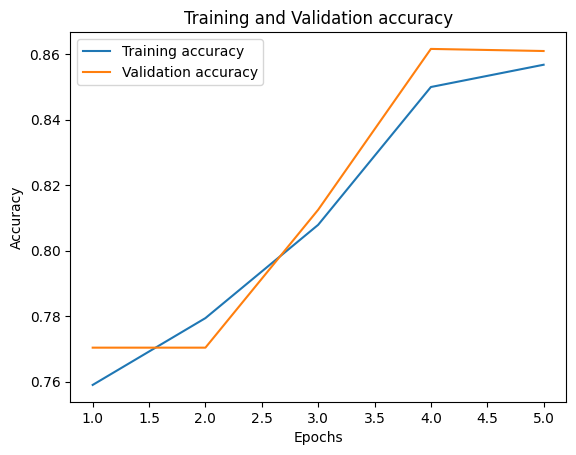

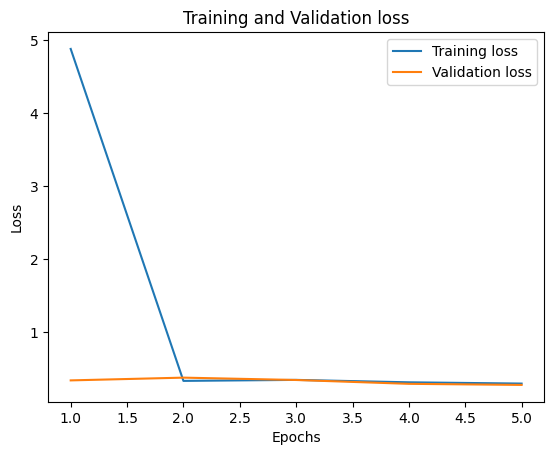

In [14]:
#Show Graphs
acc=history.history['accuracy']
val_acc=history.history['val_accuracy']
loss=history.history['loss']
val_loss=history.history['val_loss']
epochs=range(1,len(acc)+1)


#Train & Validation accuracy
plt.plot(epochs, acc, label='Training accuracy')
plt.plot(epochs,val_acc,label='Validation accuracy')
plt.title('Training and Validation accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.figure()


#Train & Validation loss
plt.plot(epochs,loss,label='Training loss')
plt.plot(epochs,val_loss,label='Validation loss')
plt.title('Training and Validation loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [16]:
#After we save the model we can load it
model=keras.models.load_model('model.vgg16.h5')

In [17]:
results=model.evaluate(test_df,verbose=1)

23/23 [==============================] - 6s 251ms/step - loss: 0.1192 - accuracy: 0.9613 - precision: 0.7143 - recall: 0.9016 - specificity_at_sensitivity: 0.9683


In [18]:
#Print classification report
y_pred=model.predict(test_df,verbose=1).round()
y_pred=y_pred.flatten()
target_names=['class non parkinson' , 'class parkinson']
print(classification_report(y_true, y_pred, target_names=target_names,digits=4))

23/23 [==============================] - 3s 126ms/step
                     precision    recall  f1-score   support

class non parkinson     0.9907    0.9668    0.9786       662
    class parkinson     0.7143    0.9016    0.7971        61

           accuracy                         0.9613       723
          macro avg     0.8525    0.9342    0.8878       723
       weighted avg     0.9674    0.9613    0.9633       723



               precision    recall  f1-score   support

    Parkinson     0.9907    0.9668    0.9786       662
Non Parkinson     0.7143    0.9016    0.7971        61

     accuracy                         0.9613       723
    macro avg     0.8525    0.9342    0.8878       723
 weighted avg     0.9674    0.9613    0.9633       723



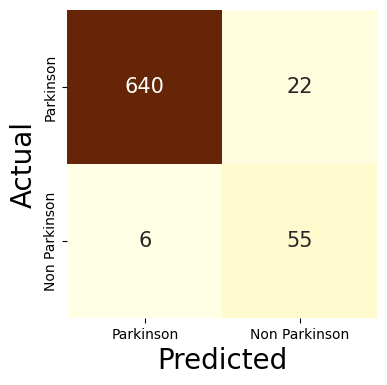

In [19]:
#Print confusion matrix
target_names=['Parkinson' , 'Non Parkinson']
report=classification_report(y_true, y_pred, target_names=target_names,digits=4)
print(report)

disp=confusion_matrix(y_true ,y_pred)
disp.astype('int')
pd.options.display.float_format='{:.5f}'.format
df_cm=pd.DataFrame(disp , target_names , target_names)
#plt.figure(figsize=(10,7))
fig,ax=plt.subplots(figsize=(4,4))
sn.set(font_scale=1.5)   #for lable size
sn.heatmap(df_cm , annot=True , annot_kws={"size":15},ax=ax,cmap="YlOrBr", fmt='g', cbar=False)
plt.ylabel('Actual',fontsize=20)
plt.xlabel('Predicted',fontsize=20)
plt.ioff()
plt.savefig("confusion_mat" ,bbox_inches='tight')
plt.show()

**DenseNet121 Model**

In [20]:
from keras.optimizers import Optimizer
OPTIMIZER=Adam(learning_rate=0.001,beta_1=0.9,beta_2=0.999)

base_model=tf.keras.applications.DenseNet121(input_shape=IMG_SHAPE,include_top=False,weights='imagenet')
base_model.trainable=True       #Not-Freezing
x=base_model.output             
x=GlobalAveragePooling2D()(x)   #Another method to Flatten
predictions=Dense(1,activation='sigmoid',name='Final')(x)     #Add output & flatten(x) to Predictions
model=Model(inputs=base_model.input ,outputs=predictions)     #Concatenate all layers(input) & Predictions(output)
#model.load_weights(dire)
model.compile(loss='binary_crossentropy',optimizer=OPTIMIZER,metrics=['accuracy',keras.metrics.Precision(),keras.metrics.Recall(),keras.metrics.SpecificityAtSensitivity(0.5)])

29084464/29084464 [==============================] - 2s 0us/step


In [21]:
#Print my model
print(model.summary())

Model: "model_1"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_2 (InputLayer)           [(None, 224, 224, 3  0           []                               
                                )]                                                                
                                                                                                  
 zero_padding2d (ZeroPadding2D)  (None, 230, 230, 3)  0          ['input_2[0][0]']                
                                                                                                  
 conv1/conv (Conv2D)            (None, 112, 112, 64  9408        ['zero_padding2d[0][0]']         
                                )                                                                 
                                                                                            

In [22]:
#Fitting for dense model
callbacks=get_callback('dense121')
history=model.fit(train_df,epochs=5,
                  validation_data=val_df,
                  callbacks=[callbacks])

Epoch 1/5
74/74 [==============================] - ETA: 0s - loss: 0.2546 - accuracy: 0.8887 - precision_1: 0.7240 - recall_1: 0.8290 - specificity_at_sensitivity_1: 0.9614
Epoch 1: saving model to model.dense121.h5
74/74 [==============================] - 120s 584ms/step - loss: 0.2546 - accuracy: 0.8887 - precision_1: 0.7240 - recall_1: 0.8290 - specificity_at_sensitivity_1: 0.9614 - val_loss: 1.1714 - val_accuracy: 0.9062 - val_precision_1: 0.7252 - val_recall_1: 0.9528 - val_specificity_at_sensitivity_1: 0.9098 - lr: 0.0010
Epoch 2/5
74/74 [==============================] - ETA: 0s - loss: 0.1711 - accuracy: 0.9167 - precision_1: 0.8021 - recall_1: 0.8439 - specificity_at_sensitivity_1: 0.9868
Epoch 2: saving model to model.dense121.h5
74/74 [==============================] - 35s 464ms/step - loss: 0.1711 - accuracy: 0.9167 - precision_1: 0.8021 - recall_1: 0.8439 - specificity_at_sensitivity_1: 0.9868 - val_loss: 31.2361 - val_accuracy: 0.2296 - val_precision_1: 0.2296 - val_recal

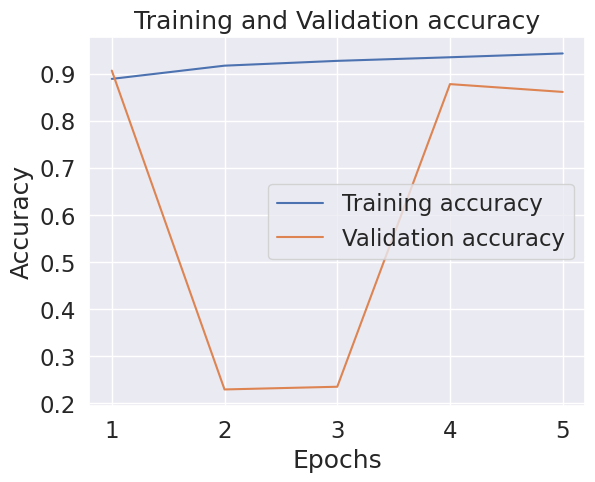

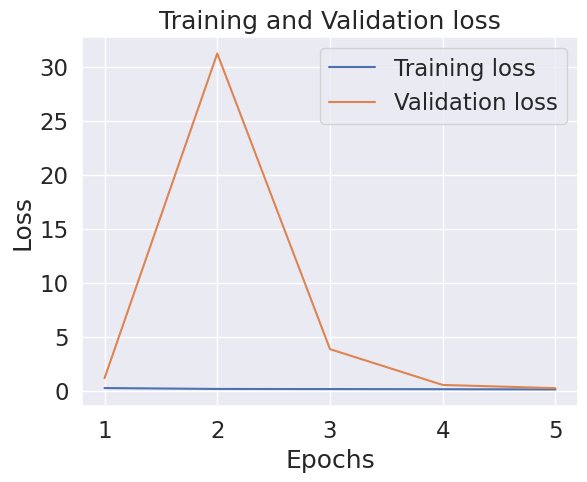

In [23]:
#Show Graphs
acc=history.history['accuracy']
val_acc=history.history['val_accuracy']
loss=history.history['loss']
val_loss=history.history['val_loss']
epochs=range(1,len(acc)+1)


#Train & Validation accuracy
plt.plot(epochs, acc, label='Training accuracy')
plt.plot(epochs,val_acc,label='Validation accuracy')
plt.title('Training and Validation accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.figure()


#Train & Validation loss
plt.plot(epochs,loss,label='Training loss')
plt.plot(epochs,val_loss,label='Validation loss')
plt.title('Training and Validation loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [24]:
#After we save the model we can load it
model=keras.models.load_model('model.dense121.h5')

In [25]:
results=model.evaluate(test_df,verbose=1)

23/23 [==============================] - 6s 171ms/step - loss: 0.1420 - accuracy: 0.9267 - precision_1: 1.0000 - recall_1: 0.1311 - specificity_at_sensitivity_1: 0.9955


In [26]:
#Print classification report
y_pred=model.predict(test_df,verbose=1).round()
y_pred=y_pred.flatten()
target_names=['class non parkinson' , 'class parkinson']
print(classification_report(y_true, y_pred, target_names=target_names,digits=4))

23/23 [==============================] - 4s 94ms/step
                     precision    recall  f1-score   support

class non parkinson     0.9259    1.0000    0.9615       662
    class parkinson     1.0000    0.1311    0.2319        61

           accuracy                         0.9267       723
          macro avg     0.9629    0.5656    0.5967       723
       weighted avg     0.9321    0.9267    0.9000       723



               precision    recall  f1-score   support

    Parkinson     0.9259    1.0000    0.9615       662
Non Parkinson     1.0000    0.1311    0.2319        61

     accuracy                         0.9267       723
    macro avg     0.9629    0.5656    0.5967       723
 weighted avg     0.9321    0.9267    0.9000       723



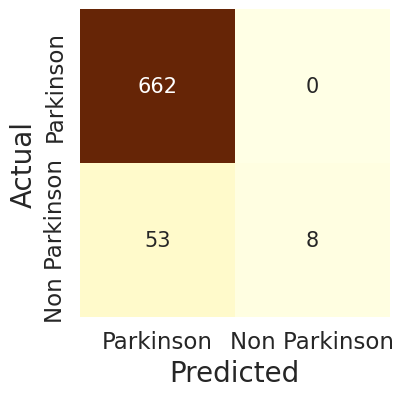

In [27]:
#Print confusion matrix
target_names=['Parkinson' , 'Non Parkinson']
report=classification_report(y_true, y_pred, target_names=target_names,digits=4)
print(report)

disp=confusion_matrix(y_true ,y_pred)
disp.astype('int')
pd.options.display.float_format='{:.5f}'.format
df_cm=pd.DataFrame(disp , target_names , target_names)
#plt.figure(figsize=(10,7))
fig,ax=plt.subplots(figsize=(4,4))
sn.set(font_scale=1.5)   #for lable size
sn.heatmap(df_cm , annot=True , annot_kws={"size":15},ax=ax,cmap="YlOrBr", fmt='g', cbar=False)
plt.ylabel('Actual',fontsize=20)
plt.xlabel('Predicted',fontsize=20)
plt.ioff()
plt.savefig("confusion_mat" ,bbox_inches='tight')
plt.show()

**Xception Model** 

In [28]:
from keras.optimizers import Optimizer
OPTIMIZER=Adam(learning_rate=0.001,beta_1=0.9,beta_2=0.999)

base_model=tf.keras.applications.Xception(input_shape=IMG_SHAPE,include_top=False,weights='imagenet')
base_model.trainable=True       #Not-Freezing
x=base_model.output             
x=GlobalAveragePooling2D()(x)   #Another method to Flatten
predictions=Dense(1,activation='sigmoid',name='Final')(x)     #Add output & flatten(x) to Predictions
model=Model(inputs=base_model.input ,outputs=predictions)     #Concatenate all layers(input) & Predictions(output)
#model.load_weights(dire)
model.compile(loss='binary_crossentropy',optimizer=OPTIMIZER,metrics=['accuracy',keras.metrics.Precision(),keras.metrics.Recall(),keras.metrics.SpecificityAtSensitivity(0.5)])

83683744/83683744 [==============================] - 5s 0us/step


In [29]:
#Print my model
print(model.summary())

Model: "model_2"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_3 (InputLayer)           [(None, 224, 224, 3  0           []                               
                                )]                                                                
                                                                                                  
 block1_conv1 (Conv2D)          (None, 111, 111, 32  864         ['input_3[0][0]']                
                                )                                                                 
                                                                                                  
 block1_conv1_bn (BatchNormaliz  (None, 111, 111, 32  128        ['block1_conv1[0][0]']           
 ation)                         )                                                           

In [30]:
#Fitting for xception model
callbacks=get_callback('xception')
history=model.fit(train_df,epochs=5,
                  validation_data=val_df,
                  callbacks=[callbacks])

Epoch 1/5
74/74 [==============================] - ETA: 0s - loss: 0.2223 - accuracy: 0.8989 - precision_2: 0.7443 - recall_2: 0.8494 - specificity_at_sensitivity_2: 0.9713
Epoch 1: saving model to model.xception.h5
74/74 [==============================] - 87s 712ms/step - loss: 0.2223 - accuracy: 0.8989 - precision_2: 0.7443 - recall_2: 0.8494 - specificity_at_sensitivity_2: 0.9713 - val_loss: 18.3209 - val_accuracy: 0.2315 - val_precision_2: 0.2300 - val_recall_2: 1.0000 - val_specificity_at_sensitivity_2: 0.0116 - lr: 0.0010
Epoch 2/5
74/74 [==============================] - ETA: 0s - loss: 0.1574 - accuracy: 0.9358 - precision_2: 0.8401 - recall_2: 0.8885 - specificity_at_sensitivity_2: 0.9890
Epoch 2: saving model to model.xception.h5
74/74 [==============================] - 50s 670ms/step - loss: 0.1574 - accuracy: 0.9358 - precision_2: 0.8401 - recall_2: 0.8885 - specificity_at_sensitivity_2: 0.9890 - val_loss: 16.8574 - val_accuracy: 0.2296 - val_precision_2: 0.2296 - val_recal

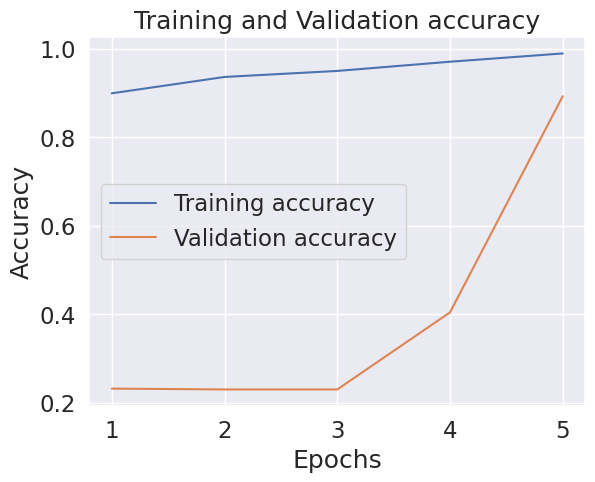

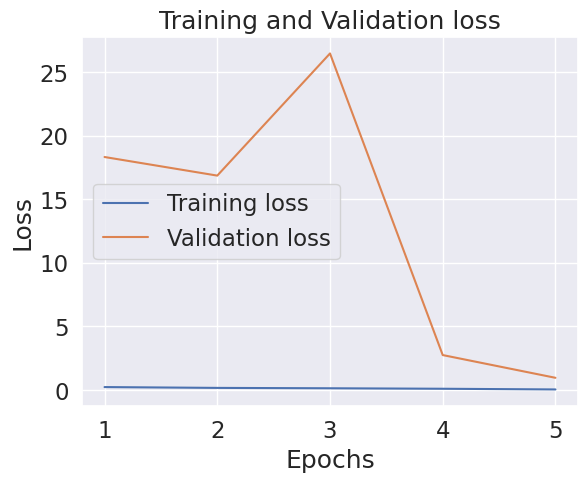

In [31]:
#Show Graphs
acc=history.history['accuracy']
val_acc=history.history['val_accuracy']
loss=history.history['loss']
val_loss=history.history['val_loss']
epochs=range(1,len(acc)+1)


#Train & Validation accuracy
plt.plot(epochs, acc, label='Training accuracy')
plt.plot(epochs,val_acc,label='Validation accuracy')
plt.title('Training and Validation accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.figure()


#Train & Validation loss
plt.plot(epochs,loss,label='Training loss')
plt.plot(epochs,val_loss,label='Validation loss')
plt.title('Training and Validation loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [32]:
#After we save the model we can load it
model=keras.models.load_model('model.xception.h5')

In [33]:
results=model.evaluate(test_df,verbose=1)

23/23 [==============================] - 6s 200ms/step - loss: 0.2727 - accuracy: 0.9696 - precision_2: 0.7349 - recall_2: 1.0000 - specificity_at_sensitivity_2: 0.9773


In [34]:
#Print classification report
y_pred=model.predict(test_df,verbose=1).round()
y_pred=y_pred.flatten()
target_names=['class non parkinson' , 'class parkinson']
print(classification_report(y_true, y_pred, target_names=target_names,digits=4))

23/23 [==============================] - 4s 149ms/step
                     precision    recall  f1-score   support

class non parkinson     1.0000    0.9668    0.9831       662
    class parkinson     0.7349    1.0000    0.8472        61

           accuracy                         0.9696       723
          macro avg     0.8675    0.9834    0.9152       723
       weighted avg     0.9776    0.9696    0.9716       723



               precision    recall  f1-score   support

    Parkinson     1.0000    0.9668    0.9831       662
Non Parkinson     0.7349    1.0000    0.8472        61

     accuracy                         0.9696       723
    macro avg     0.8675    0.9834    0.9152       723
 weighted avg     0.9776    0.9696    0.9716       723



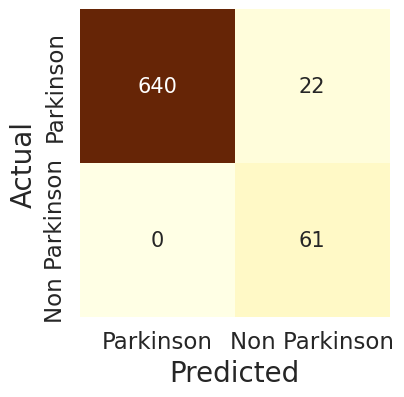

In [35]:
#Print confusion matrix
target_names=['Parkinson' , 'Non Parkinson']
report=classification_report(y_true, y_pred, target_names=target_names,digits=4)
print(report)

disp=confusion_matrix(y_true ,y_pred)
disp.astype('int')
pd.options.display.float_format='{:.5f}'.format
df_cm=pd.DataFrame(disp , target_names , target_names)
#plt.figure(figsize=(10,7))
fig,ax=plt.subplots(figsize=(4,4))
sn.set(font_scale=1.5)   #for lable size
sn.heatmap(df_cm , annot=True , annot_kws={"size":15},ax=ax,cmap="YlOrBr", fmt='g', cbar=False)
plt.ylabel('Actual',fontsize=20)
plt.xlabel('Predicted',fontsize=20)
plt.ioff()
plt.savefig("confusion_mat" ,bbox_inches='tight')
plt.show()

**MobileNetv2 Model**

In [36]:
from keras.optimizers import Optimizer
OPTIMIZER=Adam(learning_rate=0.001,beta_1=0.9,beta_2=0.999)

base_model=tf.keras.applications.MobileNetV2(input_shape=IMG_SHAPE,include_top=False,weights='imagenet')
base_model.trainable=True       #Not-Freezing
x=base_model.output             
x=GlobalAveragePooling2D()(x)   #Another method to Flatten
predictions=Dense(1,activation='sigmoid',name='Final')(x)     #Add output & flatten(x) to Predictions
model=Model(inputs=base_model.input ,outputs=predictions)     #Concatenate all layers(input) & Predictions(output)
#model.load_weights(dire)
model.compile(loss='binary_crossentropy',optimizer=OPTIMIZER,metrics=['accuracy',keras.metrics.Precision(),keras.metrics.Recall(),keras.metrics.SpecificityAtSensitivity(0.5)])

9406464/9406464 [==============================] - 1s 0us/step


In [37]:
#Print my model
print(model.summary())

Model: "model_3"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_4 (InputLayer)           [(None, 224, 224, 3  0           []                               
                                )]                                                                
                                                                                                  
 Conv1 (Conv2D)                 (None, 112, 112, 32  864         ['input_4[0][0]']                
                                )                                                                 
                                                                                                  
 bn_Conv1 (BatchNormalization)  (None, 112, 112, 32  128         ['Conv1[0][0]']                  
                                )                                                           

In [38]:
#Fitting for mobilenet model
callbacks=get_callback('mobilenet')
history=model.fit(train_df,epochs=5,
                  validation_data=val_df,
                  callbacks=[callbacks])

Epoch 1/5
74/74 [==============================] - ETA: 0s - loss: 0.2135 - accuracy: 0.8976 - precision_3: 0.7487 - recall_3: 0.8309 - specificity_at_sensitivity_3: 0.9736
Epoch 1: saving model to model.mobilenet.h5
74/74 [==============================] - 50s 248ms/step - loss: 0.2135 - accuracy: 0.8976 - precision_3: 0.7487 - recall_3: 0.8309 - specificity_at_sensitivity_3: 0.9736 - val_loss: 10.1998 - val_accuracy: 0.2296 - val_precision_3: 0.2296 - val_recall_3: 1.0000 - val_specificity_at_sensitivity_3: 0.0000e+00 - lr: 0.0010
Epoch 2/5
74/74 [==============================] - ETA: 0s - loss: 0.1587 - accuracy: 0.9227 - precision_3: 0.8346 - recall_3: 0.8253 - specificity_at_sensitivity_3: 0.9912
Epoch 2: saving model to model.mobilenet.h5
74/74 [==============================] - 17s 222ms/step - loss: 0.1587 - accuracy: 0.9227 - precision_3: 0.8346 - recall_3: 0.8253 - specificity_at_sensitivity_3: 0.9912 - val_loss: 3.3266 - val_accuracy: 0.2366 - val_precision_3: 0.2309 - val_

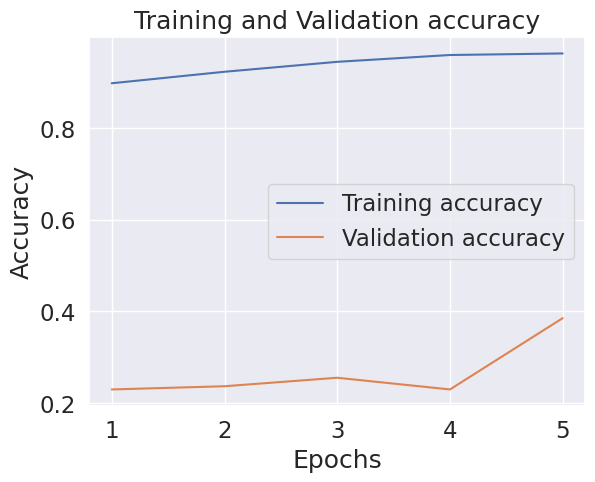

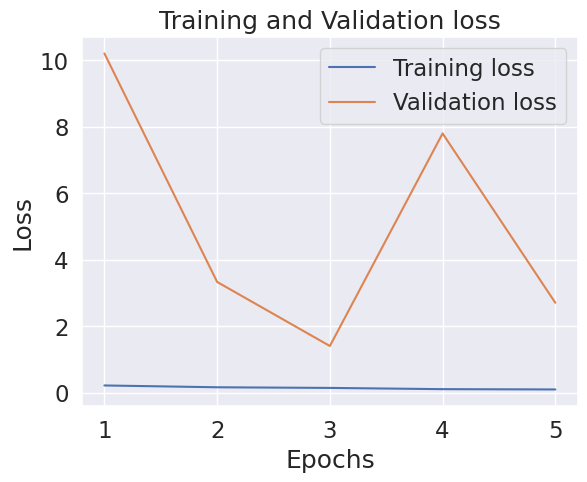

In [39]:
#Show Graphs
acc=history.history['accuracy']
val_acc=history.history['val_accuracy']
loss=history.history['loss']
val_loss=history.history['val_loss']
epochs=range(1,len(acc)+1)


#Train & Validation accuracy
plt.plot(epochs, acc, label='Training accuracy')
plt.plot(epochs,val_acc,label='Validation accuracy')
plt.title('Training and Validation accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.figure()


#Train & Validation loss
plt.plot(epochs,loss,label='Training loss')
plt.plot(epochs,val_loss,label='Validation loss')
plt.title('Training and Validation loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [40]:
#After we save the model we can load it
model=keras.models.load_model('model.mobilenet.h5')

In [41]:
results=model.evaluate(test_df,verbose=1)

23/23 [==============================] - 3s 81ms/step - loss: 4.2436 - accuracy: 0.1314 - precision_3: 0.0861 - recall_3: 0.9672 - specificity_at_sensitivity_3: 0.6042


In [42]:
#Print classification report
y_pred=model.predict(test_df,verbose=1).round()
y_pred=y_pred.flatten()
target_names=['class non parkinson' , 'class parkinson']
print(classification_report(y_true, y_pred, target_names=target_names,digits=4))

23/23 [==============================] - 2s 62ms/step
                     precision    recall  f1-score   support

class non parkinson     0.9474    0.0544    0.1029       662
    class parkinson     0.0861    0.9672    0.1582        61

           accuracy                         0.1314       723
          macro avg     0.5167    0.5108    0.1305       723
       weighted avg     0.8747    0.1314    0.1075       723



               precision    recall  f1-score   support

    Parkinson     0.9474    0.0544    0.1029       662
Non Parkinson     0.0861    0.9672    0.1582        61

     accuracy                         0.1314       723
    macro avg     0.5167    0.5108    0.1305       723
 weighted avg     0.8747    0.1314    0.1075       723



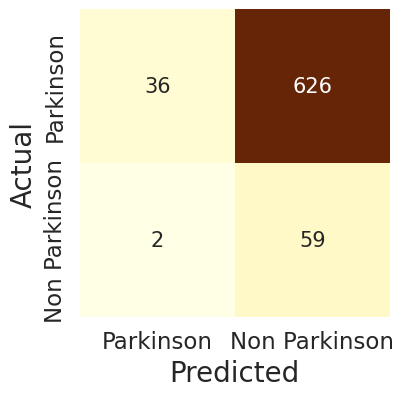

In [43]:
#Print confusion matrix
target_names=['Parkinson' , 'Non Parkinson']
report=classification_report(y_true, y_pred, target_names=target_names,digits=4)
print(report)

disp=confusion_matrix(y_true ,y_pred)
disp.astype('int')
pd.options.display.float_format='{:.5f}'.format
df_cm=pd.DataFrame(disp , target_names , target_names)
#plt.figure(figsize=(10,7))
fig,ax=plt.subplots(figsize=(4,4))
sn.set(font_scale=1.5)   #for lable size
sn.heatmap(df_cm , annot=True , annot_kws={"size":15},ax=ax,cmap="YlOrBr", fmt='g', cbar=False)
plt.ylabel('Actual',fontsize=20)
plt.xlabel('Predicted',fontsize=20)
plt.ioff()
plt.savefig("confusion_mat" ,bbox_inches='tight')
plt.show()

**ResNet50 Model**

In [44]:
from keras.optimizers import Optimizer
OPTIMIZER=Adam(learning_rate=0.001,beta_1=0.9,beta_2=0.999)

base_model=tf.keras.applications.ResNet50(input_shape=IMG_SHAPE,include_top=False,weights='imagenet')
base_model.trainable=True       #Not-Freezing
x=base_model.output             
x=GlobalAveragePooling2D()(x)   #Another method to Flatten
predictions=Dense(1,activation='sigmoid',name='Final')(x)     #Add output & flatten(x) to Predictions
model=Model(inputs=base_model.input ,outputs=predictions)     #Concatenate all layers(input) & Predictions(output)
#model.load_weights(dire)
model.compile(loss='binary_crossentropy',optimizer=OPTIMIZER,metrics=['accuracy',keras.metrics.Precision(),keras.metrics.Recall(),keras.metrics.SpecificityAtSensitivity(0.5)])

94765736/94765736 [==============================] - 5s 0us/step


In [45]:
#Print my model
print(model.summary())

Model: "model_4"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_5 (InputLayer)           [(None, 224, 224, 3  0           []                               
                                )]                                                                
                                                                                                  
 conv1_pad (ZeroPadding2D)      (None, 230, 230, 3)  0           ['input_5[0][0]']                
                                                                                                  
 conv1_conv (Conv2D)            (None, 112, 112, 64  9472        ['conv1_pad[0][0]']              
                                )                                                                 
                                                                                            

In [46]:
#Fitting for resnet model
callbacks=get_callback('resnet')
history=model.fit(train_df,epochs=5,
                  validation_data=val_df,
                  callbacks=[callbacks])

Epoch 1/5
74/74 [==============================] - ETA: 0s - loss: 0.2895 - accuracy: 0.8806 - precision_4: 0.6739 - recall_4: 0.9257 - specificity_at_sensitivity_4: 0.9350
Epoch 1: saving model to model.resnet.h5
74/74 [==============================] - 77s 482ms/step - loss: 0.2895 - accuracy: 0.8806 - precision_4: 0.6739 - recall_4: 0.9257 - specificity_at_sensitivity_4: 0.9350 - val_loss: 38.9378 - val_accuracy: 0.7704 - val_precision_4: 0.0000e+00 - val_recall_4: 0.0000e+00 - val_specificity_at_sensitivity_4: 0.0000e+00 - lr: 0.0010
Epoch 2/5
74/74 [==============================] - ETA: 0s - loss: 0.1975 - accuracy: 0.8916 - precision_4: 0.7060 - recall_4: 0.9015 - specificity_at_sensitivity_4: 0.9741
Epoch 2: saving model to model.resnet.h5
74/74 [==============================] - 40s 538ms/step - loss: 0.1975 - accuracy: 0.8916 - precision_4: 0.7060 - recall_4: 0.9015 - specificity_at_sensitivity_4: 0.9741 - val_loss: 1.1422 - val_accuracy: 0.7704 - val_precision_4: 0.5000 - va

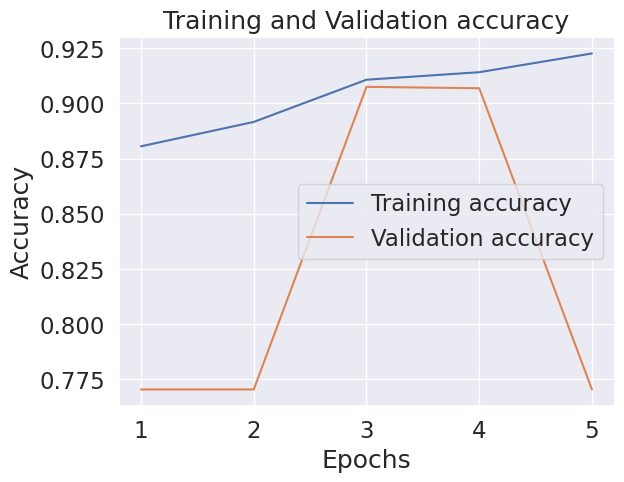

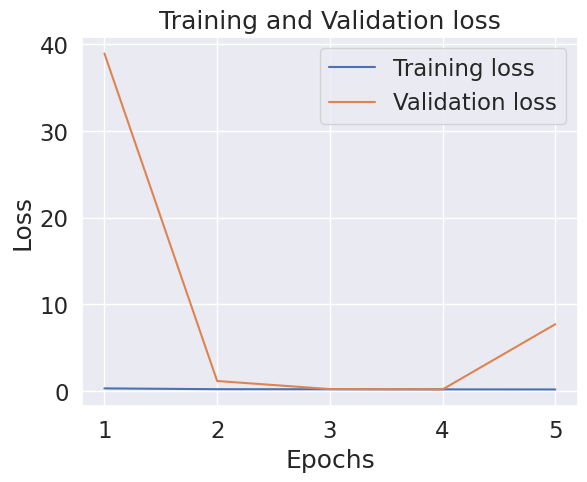

In [47]:
#Show Graphs
acc=history.history['accuracy']
val_acc=history.history['val_accuracy']
loss=history.history['loss']
val_loss=history.history['val_loss']
epochs=range(1,len(acc)+1)


#Train & Validation accuracy
plt.plot(epochs, acc, label='Training accuracy')
plt.plot(epochs,val_acc,label='Validation accuracy')
plt.title('Training and Validation accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.figure()


#Train & Validation loss
plt.plot(epochs,loss,label='Training loss')
plt.plot(epochs,val_loss,label='Validation loss')
plt.title('Training and Validation loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [48]:
#After we save the model we can load it
model=keras.models.load_model('model.resnet.h5')

In [49]:
results=model.evaluate(test_df,verbose=1)

23/23 [==============================] - 5s 131ms/step - loss: 2.3507 - accuracy: 0.9156 - precision_4: 0.0000e+00 - recall_4: 0.0000e+00 - specificity_at_sensitivity_4: 0.0000e+00


In [50]:
#Print classification report
y_pred=model.predict(test_df,verbose=1).round()
y_pred=y_pred.flatten()
target_names=['class non parkinson' , 'class parkinson']
print(classification_report(y_true, y_pred, target_names=target_names,digits=4))

23/23 [==============================] - 3s 99ms/step
                     precision    recall  f1-score   support

class non parkinson     0.9156    1.0000    0.9560       662
    class parkinson     0.0000    0.0000    0.0000        61

           accuracy                         0.9156       723
          macro avg     0.4578    0.5000    0.4780       723
       weighted avg     0.8384    0.9156    0.8753       723



/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


               precision    recall  f1-score   support

    Parkinson     0.9156    1.0000    0.9560       662
Non Parkinson     0.0000    0.0000    0.0000        61

     accuracy                         0.9156       723
    macro avg     0.4578    0.5000    0.4780       723
 weighted avg     0.8384    0.9156    0.8753       723



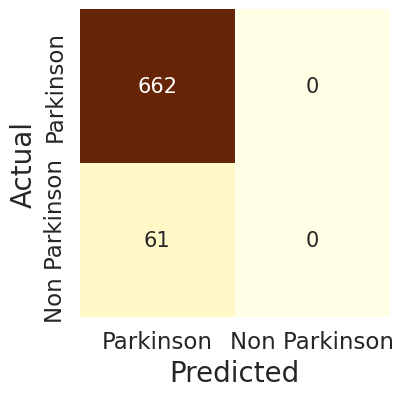

In [51]:
#Print confusion matrix
target_names=['Parkinson' , 'Non Parkinson']
report=classification_report(y_true, y_pred, target_names=target_names,digits=4)
print(report)

disp=confusion_matrix(y_true ,y_pred)
disp.astype('int')
pd.options.display.float_format='{:.5f}'.format
df_cm=pd.DataFrame(disp , target_names , target_names)
#plt.figure(figsize=(10,7))
fig,ax=plt.subplots(figsize=(4,4))
sn.set(font_scale=1.5)   #for lable size
sn.heatmap(df_cm , annot=True , annot_kws={"size":15},ax=ax,cmap="YlOrBr", fmt='g', cbar=False)
plt.ylabel('Actual',fontsize=20)
plt.xlabel('Predicted',fontsize=20)
plt.ioff()
plt.savefig("confusion_mat" ,bbox_inches='tight')
plt.show()

**InceptionV3 Model**

In [52]:
from keras.optimizers import Optimizer
OPTIMIZER=Adam(learning_rate=0.001,beta_1=0.9,beta_2=0.999)

base_model=tf.keras.applications.InceptionV3(input_shape=IMG_SHAPE,include_top=False,weights='imagenet')
base_model.trainable=True       #Not-Freezing
x=base_model.output             
x=GlobalAveragePooling2D()(x)   #Another method to Flatten
predictions=Dense(1,activation='sigmoid',name='Final')(x)     #Add output & flatten(x) to Predictions
model=Model(inputs=base_model.input ,outputs=predictions)     #Concatenate all layers(input) & Predictions(output)
#model.load_weights(dire)
model.compile(loss='binary_crossentropy',optimizer=OPTIMIZER,metrics=['accuracy',keras.metrics.Precision(),keras.metrics.Recall(),keras.metrics.SpecificityAtSensitivity(0.5)])

87910968/87910968 [==============================] - 5s 0us/step


In [53]:
#Print my model
print(model.summary())

Model: "model_5"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_6 (InputLayer)           [(None, 224, 224, 3  0           []                               
                                )]                                                                
                                                                                                  
 conv2d_4 (Conv2D)              (None, 111, 111, 32  864         ['input_6[0][0]']                
                                )                                                                 
                                                                                                  
 batch_normalization_4 (BatchNo  (None, 111, 111, 32  96         ['conv2d_4[0][0]']               
 rmalization)                   )                                                           

In [54]:
#Fitting for inception model
callbacks=get_callback('inception')
history=model.fit(train_df,epochs=5,
                  validation_data=val_df,
                  callbacks=[callbacks])

Epoch 1/5
74/74 [==============================] - ETA: 0s - loss: 0.2686 - accuracy: 0.8759 - precision_5: 0.6820 - recall_5: 0.8569 - specificity_at_sensitivity_5: 0.9587
Epoch 1: saving model to model.inception.h5
74/74 [==============================] - 77s 442ms/step - loss: 0.2686 - accuracy: 0.8759 - precision_5: 0.6820 - recall_5: 0.8569 - specificity_at_sensitivity_5: 0.9587 - val_loss: 0.9112 - val_accuracy: 0.6473 - val_precision_5: 0.0469 - val_recall_5: 0.0278 - val_specificity_at_sensitivity_5: 0.0927 - lr: 0.0010
Epoch 2/5
74/74 [==============================] - ETA: 0s - loss: 0.1881 - accuracy: 0.9116 - precision_5: 0.7759 - recall_5: 0.8625 - specificity_at_sensitivity_5: 0.9829
Epoch 2: saving model to model.inception.h5
74/74 [==============================] - 31s 420ms/step - loss: 0.1881 - accuracy: 0.9116 - precision_5: 0.7759 - recall_5: 0.8625 - specificity_at_sensitivity_5: 0.9829 - val_loss: 0.3197 - val_accuracy: 0.8329 - val_precision_5: 0.9298 - val_recal

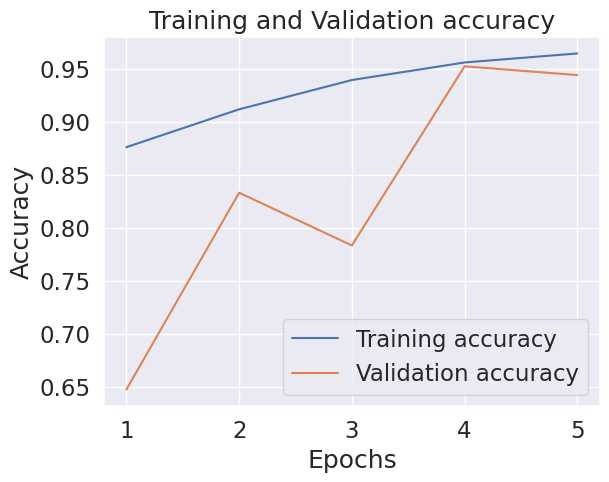

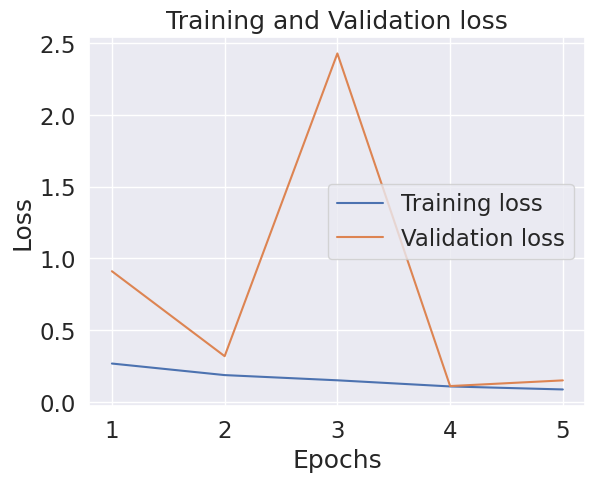

In [55]:
#Show Graphs
acc=history.history['accuracy']
val_acc=history.history['val_accuracy']
loss=history.history['loss']
val_loss=history.history['val_loss']
epochs=range(1,len(acc)+1)


#Train & Validation accuracy
plt.plot(epochs, acc, label='Training accuracy')
plt.plot(epochs,val_acc,label='Validation accuracy')
plt.title('Training and Validation accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.figure()


#Train & Validation loss
plt.plot(epochs,loss,label='Training loss')
plt.plot(epochs,val_loss,label='Validation loss')
plt.title('Training and Validation loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [56]:
#After we save the model we can load it
model=keras.models.load_model('model.inception.h5')

In [57]:
results=model.evaluate(test_df,verbose=1)

23/23 [==============================] - 4s 131ms/step - loss: 0.1437 - accuracy: 0.9557 - precision_5: 0.9143 - recall_5: 0.5246 - specificity_at_sensitivity_5: 0.9955


In [58]:
#Print classification report
y_pred=model.predict(test_df,verbose=1).round()
y_pred=y_pred.flatten()
target_names=['class non parkinson' , 'class parkinson']
print(classification_report(y_true, y_pred, target_names=target_names,digits=4))

23/23 [==============================] - 3s 70ms/step
                     precision    recall  f1-score   support

class non parkinson     0.9578    0.9955    0.9763       662
    class parkinson     0.9143    0.5246    0.6667        61

           accuracy                         0.9557       723
          macro avg     0.9361    0.7600    0.8215       723
       weighted avg     0.9542    0.9557    0.9502       723



               precision    recall  f1-score   support

    Parkinson     0.9578    0.9955    0.9763       662
Non Parkinson     0.9143    0.5246    0.6667        61

     accuracy                         0.9557       723
    macro avg     0.9361    0.7600    0.8215       723
 weighted avg     0.9542    0.9557    0.9502       723



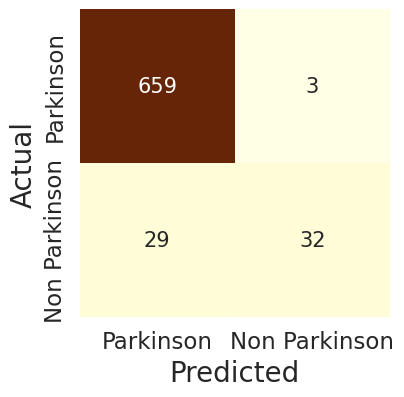

In [59]:
#Print confusion matrix
target_names=['Parkinson' , 'Non Parkinson']
report=classification_report(y_true, y_pred, target_names=target_names,digits=4)
print(report)

disp=confusion_matrix(y_true ,y_pred)
disp.astype('int')
pd.options.display.float_format='{:.5f}'.format
df_cm=pd.DataFrame(disp , target_names , target_names)
#plt.figure(figsize=(10,7))
fig,ax=plt.subplots(figsize=(4,4))
sn.set(font_scale=1.5)   #for lable size
sn.heatmap(df_cm , annot=True , annot_kws={"size":15},ax=ax,cmap="YlOrBr", fmt='g', cbar=False)
plt.ylabel('Actual',fontsize=20)
plt.xlabel('Predicted',fontsize=20)
plt.ioff()
plt.savefig("confusion_mat" ,bbox_inches='tight')
plt.show()

**InceptionResNetV2 Model**

In [63]:
from keras.optimizers import Optimizer
OPTIMIZER=Adam(learning_rate=0.001,beta_1=0.9,beta_2=0.999)

base_model=tf.keras.applications.InceptionResNetV2(input_shape=IMG_SHAPE,include_top=False,weights='imagenet')
base_model.trainable=True       #Not-Freezing
x=base_model.output             
x=GlobalAveragePooling2D()(x)   #Another method to Flatten
predictions=Dense(1,activation='sigmoid',name='Final')(x)     #Add output & flatten(x) to Predictions
model=Model(inputs=base_model.input ,outputs=predictions)     #Concatenate all layers(input) & Predictions(output)
#model.load_weights(dire)
model.compile(loss='binary_crossentropy',optimizer=OPTIMIZER,metrics=['accuracy',keras.metrics.Precision(),keras.metrics.Recall(),keras.metrics.SpecificityAtSensitivity(0.5)])

219055592/219055592 [==============================] - 11s 0us/step


In [64]:
#Print my model
print(model.summary())

Model: "model_7"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_8 (InputLayer)           [(None, 224, 224, 3  0           []                               
                                )]                                                                
                                                                                                  
 conv2d_98 (Conv2D)             (None, 111, 111, 32  864         ['input_8[0][0]']                
                                )                                                                 
                                                                                                  
 batch_normalization_98 (BatchN  (None, 111, 111, 32  96         ['conv2d_98[0][0]']              
 ormalization)                  )                                                           

In [65]:
#Fitting for InceptionResNetV2 model
callbacks=get_callback('InceptionResNetV2')
history=model.fit(train_df,epochs=5,
                  validation_data=val_df,
                  callbacks=[callbacks])

Epoch 1/5
74/74 [==============================] - ETA: 0s - loss: 0.2565 - accuracy: 0.8912 - precision_7: 0.7334 - recall_7: 0.8234 - specificity_at_sensitivity_7: 0.9691
Epoch 1: saving model to model.InceptionResNetV2.h5
74/74 [==============================] - 166s 883ms/step - loss: 0.2565 - accuracy: 0.8912 - precision_7: 0.7334 - recall_7: 0.8234 - specificity_at_sensitivity_7: 0.9691 - val_loss: 6.1420 - val_accuracy: 0.8240 - val_precision_7: 0.8182 - val_recall_7: 0.3000 - val_specificity_at_sensitivity_7: 0.2674 - lr: 0.0010
Epoch 2/5
74/74 [==============================] - ETA: 0s - loss: 0.1403 - accuracy: 0.9384 - precision_7: 0.8314 - recall_7: 0.9164 - specificity_at_sensitivity_7: 0.9934
Epoch 2: saving model to model.InceptionResNetV2.h5
74/74 [==============================] - 92s 1s/step - loss: 0.1403 - accuracy: 0.9384 - precision_7: 0.8314 - recall_7: 0.9164 - specificity_at_sensitivity_7: 0.9934 - val_loss: 0.2121 - val_accuracy: 0.8929 - val_precision_7: 0.96

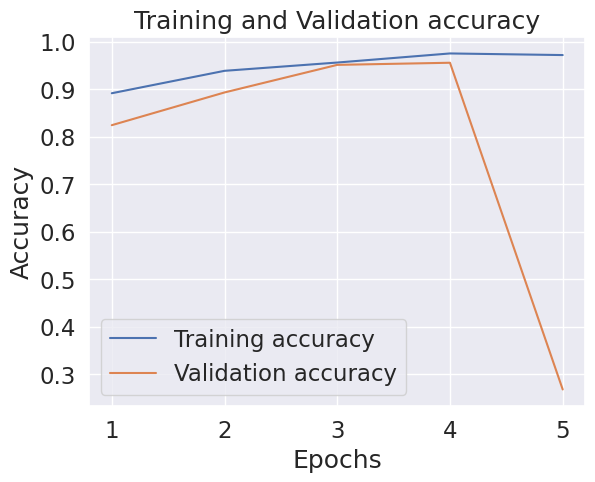

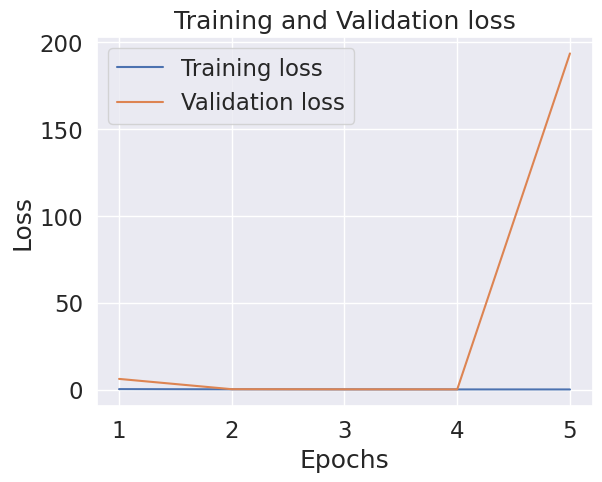

In [66]:
#Show Graphs
acc=history.history['accuracy']
val_acc=history.history['val_accuracy']
loss=history.history['loss']
val_loss=history.history['val_loss']
epochs=range(1,len(acc)+1)


#Train & Validation accuracy
plt.plot(epochs, acc, label='Training accuracy')
plt.plot(epochs,val_acc,label='Validation accuracy')
plt.title('Training and Validation accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.figure()


#Train & Validation loss
plt.plot(epochs,loss,label='Training loss')
plt.plot(epochs,val_loss,label='Validation loss')
plt.title('Training and Validation loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [67]:
#After we save the model we can load it
model=keras.models.load_model('model.InceptionResNetV2.h5') 

In [68]:
results=model.evaluate(test_df,verbose=1)

23/23 [==============================] - 10s 217ms/step - loss: 66.3853 - accuracy: 0.4467 - precision_7: 0.1242 - recall_7: 0.9180 - specificity_at_sensitivity_7: 0.4335


In [69]:
#Print classification report
y_pred=model.predict(test_df,verbose=1).round()
y_pred=y_pred.flatten()
target_names=['class non parkinson' , 'class parkinson']
print(classification_report(y_true, y_pred, target_names=target_names,digits=4))

23/23 [==============================] - 7s 181ms/step
                     precision    recall  f1-score   support

class non parkinson     0.9816    0.4033    0.5717       662
    class parkinson     0.1242    0.9180    0.2188        61

           accuracy                         0.4467       723
          macro avg     0.5529    0.6607    0.3952       723
       weighted avg     0.9093    0.4467    0.5420       723



               precision    recall  f1-score   support

    Parkinson     0.9816    0.4033    0.5717       662
Non Parkinson     0.1242    0.9180    0.2188        61

     accuracy                         0.4467       723
    macro avg     0.5529    0.6607    0.3952       723
 weighted avg     0.9093    0.4467    0.5420       723



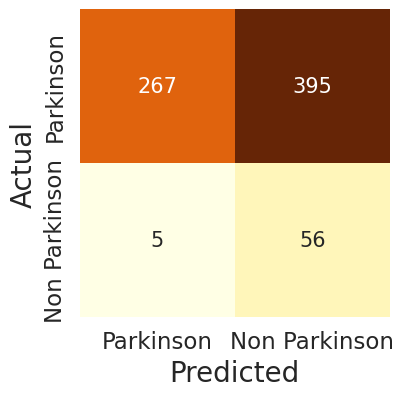

In [70]:
#Print confusion matrix
target_names=['Parkinson' , 'Non Parkinson']
report=classification_report(y_true, y_pred, target_names=target_names,digits=4)
print(report)

disp=confusion_matrix(y_true ,y_pred)
disp.astype('int')
pd.options.display.float_format='{:.5f}'.format
df_cm=pd.DataFrame(disp , target_names , target_names)
#plt.figure(figsize=(10,7))
fig,ax=plt.subplots(figsize=(4,4))
sn.set(font_scale=1.5)   #for lable size
sn.heatmap(df_cm , annot=True , annot_kws={"size":15},ax=ax,cmap="YlOrBr", fmt='g', cbar=False)
plt.ylabel('Actual',fontsize=20)
plt.xlabel('Predicted',fontsize=20)
plt.ioff()
plt.savefig("confusion_mat" ,bbox_inches='tight')
plt.show()

**DenseNet201 Model**

In [72]:
from keras.optimizers import Optimizer
OPTIMIZER=Adam(learning_rate=0.001,beta_1=0.9,beta_2=0.999)

base_model=tf.keras.applications.DenseNet201(input_shape=IMG_SHAPE,include_top=False,weights='imagenet')
base_model.trainable=True       #Not-Freezing
x=base_model.output             
x=GlobalAveragePooling2D()(x)   #Another method to Flatten
predictions=Dense(1,activation='sigmoid',name='Final')(x)     #Add output & flatten(x) to Predictions
model=Model(inputs=base_model.input ,outputs=predictions)     #Concatenate all layers(input) & Predictions(output)
#model.load_weights(dire)
model.compile(loss='binary_crossentropy',optimizer=OPTIMIZER,metrics=['accuracy',keras.metrics.Precision(),keras.metrics.Recall(),keras.metrics.SpecificityAtSensitivity(0.5)])

74836368/74836368 [==============================] - 4s 0us/step


In [73]:
#Print my model
print(model.summary())

Model: "model_8"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_10 (InputLayer)          [(None, 224, 224, 3  0           []                               
                                )]                                                                
                                                                                                  
 zero_padding2d_2 (ZeroPadding2  (None, 230, 230, 3)  0          ['input_10[0][0]']               
 D)                                                                                               
                                                                                                  
 conv1/conv (Conv2D)            (None, 112, 112, 64  9408        ['zero_padding2d_2[0][0]']       
                                )                                                           

In [74]:
#Fitting for DenseNet201 model
callbacks=get_callback('DenseNet201')
history=model.fit(train_df,epochs=5,
                  validation_data=val_df,
                  callbacks=[callbacks])

Epoch 1/5
74/74 [==============================] - ETA: 0s - loss: 0.2820 - accuracy: 0.8823 - precision_8: 0.7216 - recall_8: 0.7900 - specificity_at_sensitivity_8: 0.9548
Epoch 1: saving model to model.DenseNet201.h5
74/74 [==============================] - 198s 896ms/step - loss: 0.2820 - accuracy: 0.8823 - precision_8: 0.7216 - recall_8: 0.7900 - specificity_at_sensitivity_8: 0.9548 - val_loss: 1.1061 - val_accuracy: 0.8820 - val_precision_8: 0.6606 - val_recall_8: 1.0000 - val_specificity_at_sensitivity_8: 0.8841 - lr: 0.0010
Epoch 2/5
74/74 [==============================] - ETA: 0s - loss: 0.1769 - accuracy: 0.9197 - precision_8: 0.8024 - recall_8: 0.8606 - specificity_at_sensitivity_8: 0.9796
Epoch 2: saving model to model.DenseNet201.h5
74/74 [==============================] - 63s 848ms/step - loss: 0.1769 - accuracy: 0.9197 - precision_8: 0.8024 - recall_8: 0.8606 - specificity_at_sensitivity_8: 0.9796 - val_loss: 2.3822 - val_accuracy: 0.8763 - val_precision_8: 0.6509 - val_

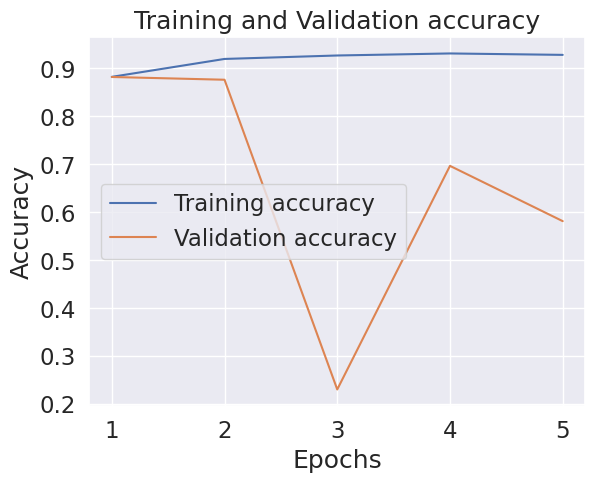

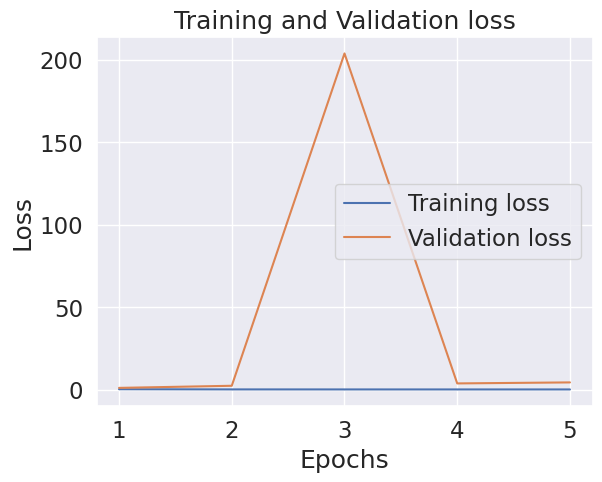

In [75]:
#Show Graphs
acc=history.history['accuracy']
val_acc=history.history['val_accuracy']
loss=history.history['loss']
val_loss=history.history['val_loss']
epochs=range(1,len(acc)+1)


#Train & Validation accuracy
plt.plot(epochs, acc, label='Training accuracy')
plt.plot(epochs,val_acc,label='Validation accuracy')
plt.title('Training and Validation accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.figure()


#Train & Validation loss
plt.plot(epochs,loss,label='Training loss')
plt.plot(epochs,val_loss,label='Validation loss')
plt.title('Training and Validation loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [76]:
#After we save the model we can load it
model=keras.models.load_model('model.DenseNet201.h5') 

In [78]:
results=model.evaluate(test_df,verbose=1)

23/23 [==============================] - 11s 220ms/step - loss: 1.9114 - accuracy: 0.6528 - precision_8: 0.1935 - recall_8: 0.9836 - specificity_at_sensitivity_8: 0.8580


In [80]:
#Print classification report
y_pred=model.predict(test_df,verbose=1).round()
y_pred=y_pred.flatten()
target_names=['class non parkinson' , 'class parkinson']
print(classification_report(y_true, y_pred, target_names=target_names,digits=4))

23/23 [==============================] - 7s 155ms/step
                     precision    recall  f1-score   support

class non parkinson     0.9976    0.6224    0.7665       662
    class parkinson     0.1935    0.9836    0.3235        61

           accuracy                         0.6528       723
          macro avg     0.5956    0.8030    0.5450       723
       weighted avg     0.9297    0.6528    0.7291       723



               precision    recall  f1-score   support

    Parkinson     0.9976    0.6224    0.7665       662
Non Parkinson     0.1935    0.9836    0.3235        61

     accuracy                         0.6528       723
    macro avg     0.5956    0.8030    0.5450       723
 weighted avg     0.9297    0.6528    0.7291       723



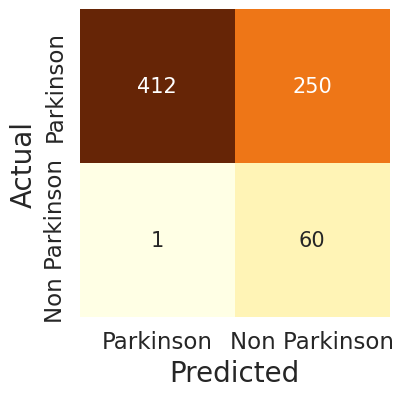

In [81]:
#Print confusion matrix
target_names=['Parkinson' , 'Non Parkinson']
report=classification_report(y_true, y_pred, target_names=target_names,digits=4)
print(report)

disp=confusion_matrix(y_true ,y_pred)
disp.astype('int')
pd.options.display.float_format='{:.5f}'.format
df_cm=pd.DataFrame(disp , target_names , target_names)
#plt.figure(figsize=(10,7))
fig,ax=plt.subplots(figsize=(4,4))
sn.set(font_scale=1.5)   #for lable size
sn.heatmap(df_cm , annot=True , annot_kws={"size":15},ax=ax,cmap="YlOrBr", fmt='g', cbar=False)
plt.ylabel('Actual',fontsize=20)
plt.xlabel('Predicted',fontsize=20)
plt.ioff()
plt.savefig("confusion_mat" ,bbox_inches='tight')
plt.show()